In [20]:
import numpy as np
import xarray as xr
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmcrameri.cm as cm

In [3]:
# Constants

FIRST_YEAR = 2000
LAST_YEAR = 2023
N_YEARS = LAST_YEAR - FIRST_YEAR + 1
N = 365 * 24 * N_YEARS + 6 * 24   # 24 extra hours for 6 leap years
COVERAGE_THRESHOLD = 0.9
ZSCORE_THRESHOLD = 5  # for outlier detection; may want to adjust (this seems to reject some plausible Wind Spd values, for instance)
vars = [
    "Wind Spd (km/h)",
]

WATER_YEARS = {
    year: [
        [year - 1, 10],
        [year - 1, 11],
        [year - 1, 12],
        [year, 1],
        [year, 2],
        [year, 3],
        [year, 4],
        [year, 5],
        [year, 6],
        [year, 7],
        [year, 8],
        [year, 9],
    ] for year in range(FIRST_YEAR, LAST_YEAR + 1)
}

In [4]:
def readable_time_coord(ds, time_var='Times'):

    time_vals = ds[time_var].values

    # Extract integer (YYYYMMDD) and fractional day parts
    dates_int = time_vals.astype(int)
    frac_days = time_vals - dates_int

    # Parse integers to datetime
    base_dates = pd.to_datetime(dates_int.astype(str), format="%Y%m%d")

    # Add fractional day as timedelta
    full_times = base_dates + pd.to_timedelta(frac_days, unit="D")
    full_times = full_times.round("1h")

    # Assign back to dataset
    ds = ds.assign_coords({time_var: full_times})
    ds = ds.transpose(time_var, ...)

    ds = ds.rename({time_var: "time"})

    return ds

In [5]:
winds_ymonmean_ds = xr.open_dataset("/users/rpayne/data/unproc/WRF-UBC/WS10/WS10_ymonmean_199010_202309.nc")
winds_ymonmean_ds = winds_ymonmean_ds.assign_coords(Times=np.arange(1, 13))
winds_yyearmean_ds = winds_ymonmean_ds.mean(dim='Times')

winds_max_ymonmean_ds = xr.open_dataset("/users/rpayne/data/unproc/WRF-UBC/WS10/WS10_dailymax_ymonmean_199010_202309.nc")
winds_max_ymonmean_ds = winds_max_ymonmean_ds.assign_coords(Times=np.arange(1, 13))
winds_max_yyearmean_ds = winds_max_ymonmean_ds.mean(dim='Times')

winds_ymonmean_ds

<xarray.Dataset> Size: 22MB
Dimensions:  (south_north: 702, west_east: 558, Times: 12)
Coordinates:
    XLONG    (south_north, west_east) float32 2MB ...
    XLAT     (south_north, west_east) float32 2MB ...
  * Times    (Times) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: south_north, west_east
Data variables:
    WS10     (Times, south_north, west_east) float32 19MB 8.542 8.539 ... 3.647
Attributes: (12/90)
    CDI:                             Climate Data Interface version 1.9.9rc1 ...
    Conventions:                     CF-1.6
    history:                         Wed Jul 30 14:05:16 2025: cdo ymonmean ....
    TITLE:                            OUTPUT FROM WRF V4.4.2 MODEL
    START_DATE:                      1999-10-01_00:00:00
    WEST-EAST_GRID_DIMENSION:        559
    ...                              ...
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      2
    ETAC:                            0.2
    CDO:                             Climate Data Operators version 1.9.9rc1 ...

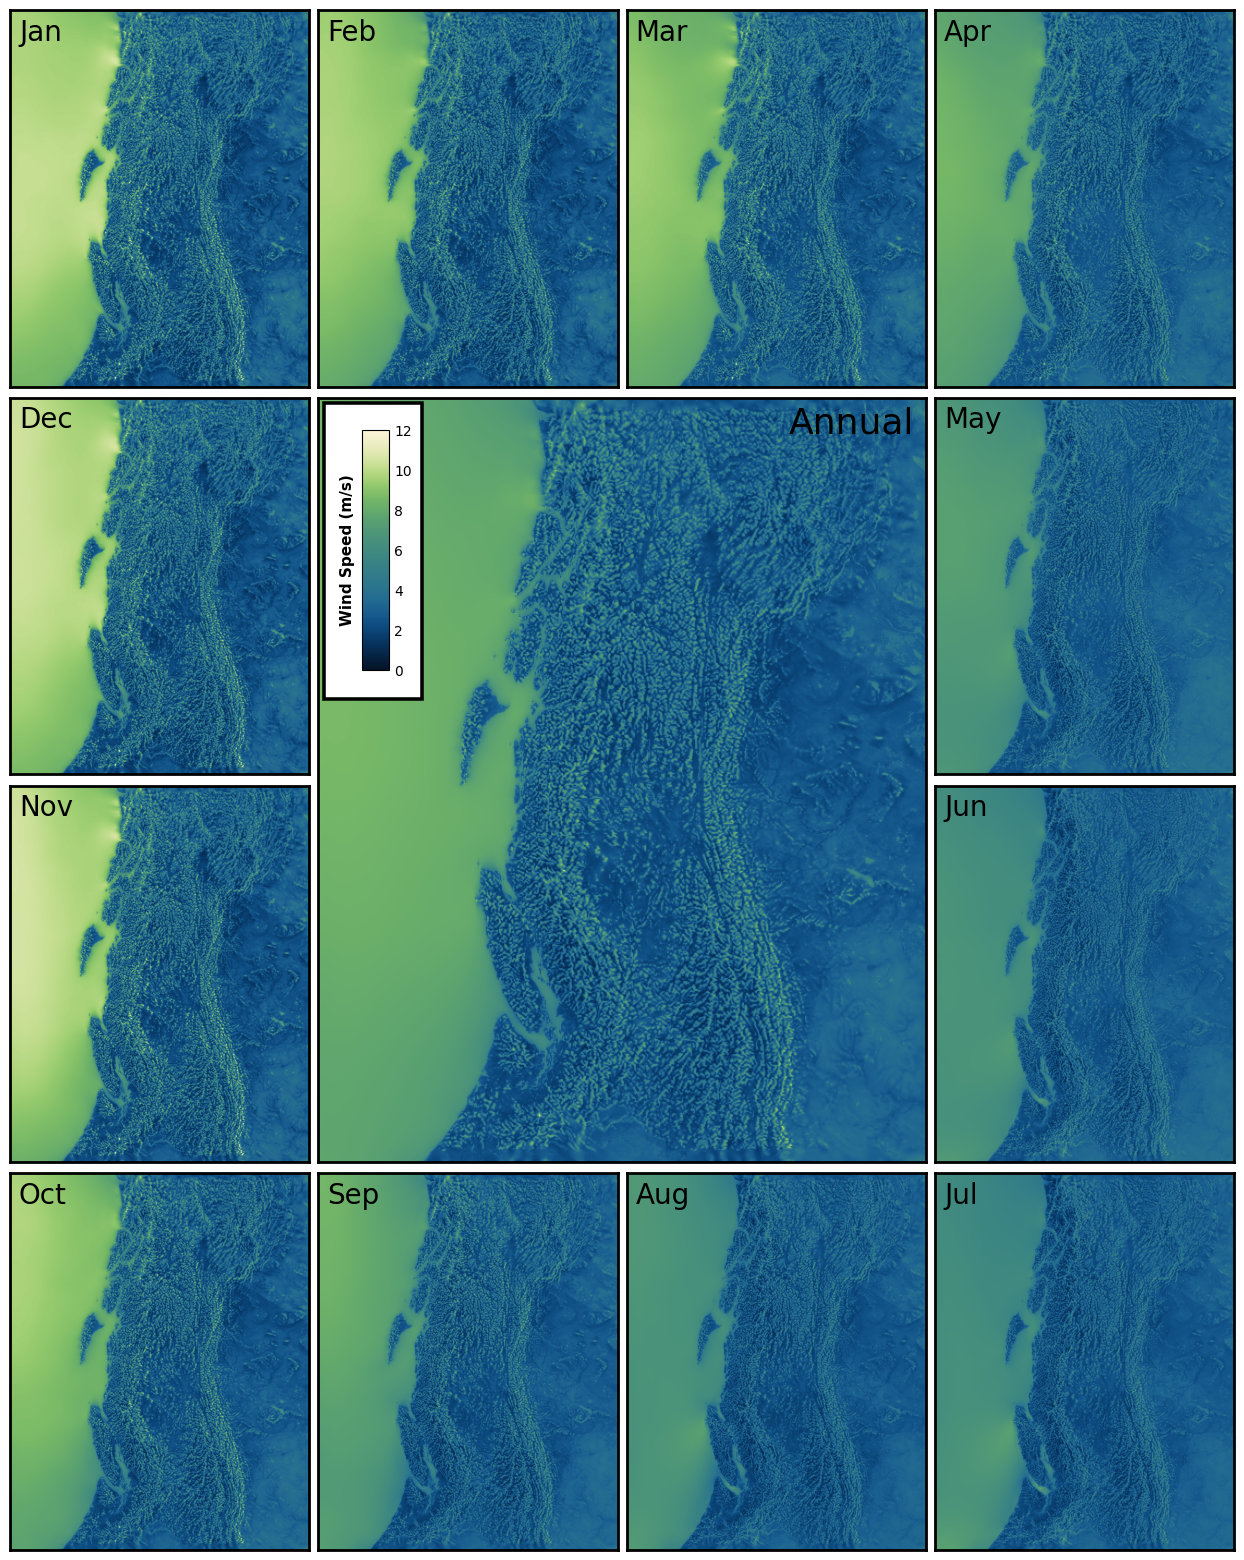

In [58]:
data = [winds_ymonmean_ds.isel(Times=i)['WS10'].values for i in range(12)] + [winds_yyearmean_ds['WS10'].values]
titles = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul',
          'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Annual']

# Set up figure and GridSpec layout
fig = plt.figure(figsize=(15.8, 20))
gs = gridspec.GridSpec(4, 4, figure=fig, wspace=0.03, hspace=0.03)

# Index map for where each panel goes (row, col)
positions = {
    'Jan':  (0, 0), 'Feb':  (0, 1), 'Mar':  (0, 2), 'Apr':  (0, 3),
    'May':  (1, 3), 'Jun':  (2, 3), 'Jul':  (3, 3), 'Aug':  (3, 2),
    'Sep':  (3, 1), 'Oct':  (3, 0), 'Nov':  (2, 0), 'Dec':  (1, 0),
    'Annual': (1, 1)  # Annual goes in the center and spans multiple rows/cols
}

# Add the plots
for i, name in enumerate(titles):
    if name == 'Annual':
        ax = fig.add_subplot(gs[1:3, 1:3])  # Larger annual plot
        ax.set_title(name, loc='right', fontsize=26, pad=-26, x=.98, y=1.000001)

        # white box on which the colorbar will be placed and its black border:
        ax.plot([50, 50],[470,652], linewidth=68, color='w', alpha=1.)
        ax.add_patch(Rectangle((6, 426), 88, 270, linewidth=4, edgecolor='black', facecolor='none', alpha=1.))

    else:
        row, col = positions[name]
        ax = fig.add_subplot(gs[row, col])
        ax.set_title(name, loc='left', fontsize=20, pad=-22, x=0.03, y=1.000001)

    im = ax.imshow(data[i], cmap=cm.navia, vmin=0, vmax=12, origin='lower',)

    ax.set_frame_on(True)
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')
        spine.set_linewidth(2)

# Add shared colorbar
cbar_ax = fig.add_axes([0.348, 0.550, 0.017, 0.12])  # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cbar_ax.yaxis.set_label_position('left')
cbar_ax.set_ylabel('Wind Speed (m/s)', rotation=90, labelpad=5, fontsize=11, weight='bold')
cbar_ax.tick_params(axis='y', length=0)

fig.savefig('/users/rpayne/ClimatExWRF/Robert/results/WRF_UBC_WS10_annualcycle.png', dpi=200, bbox_inches='tight')
plt.show()

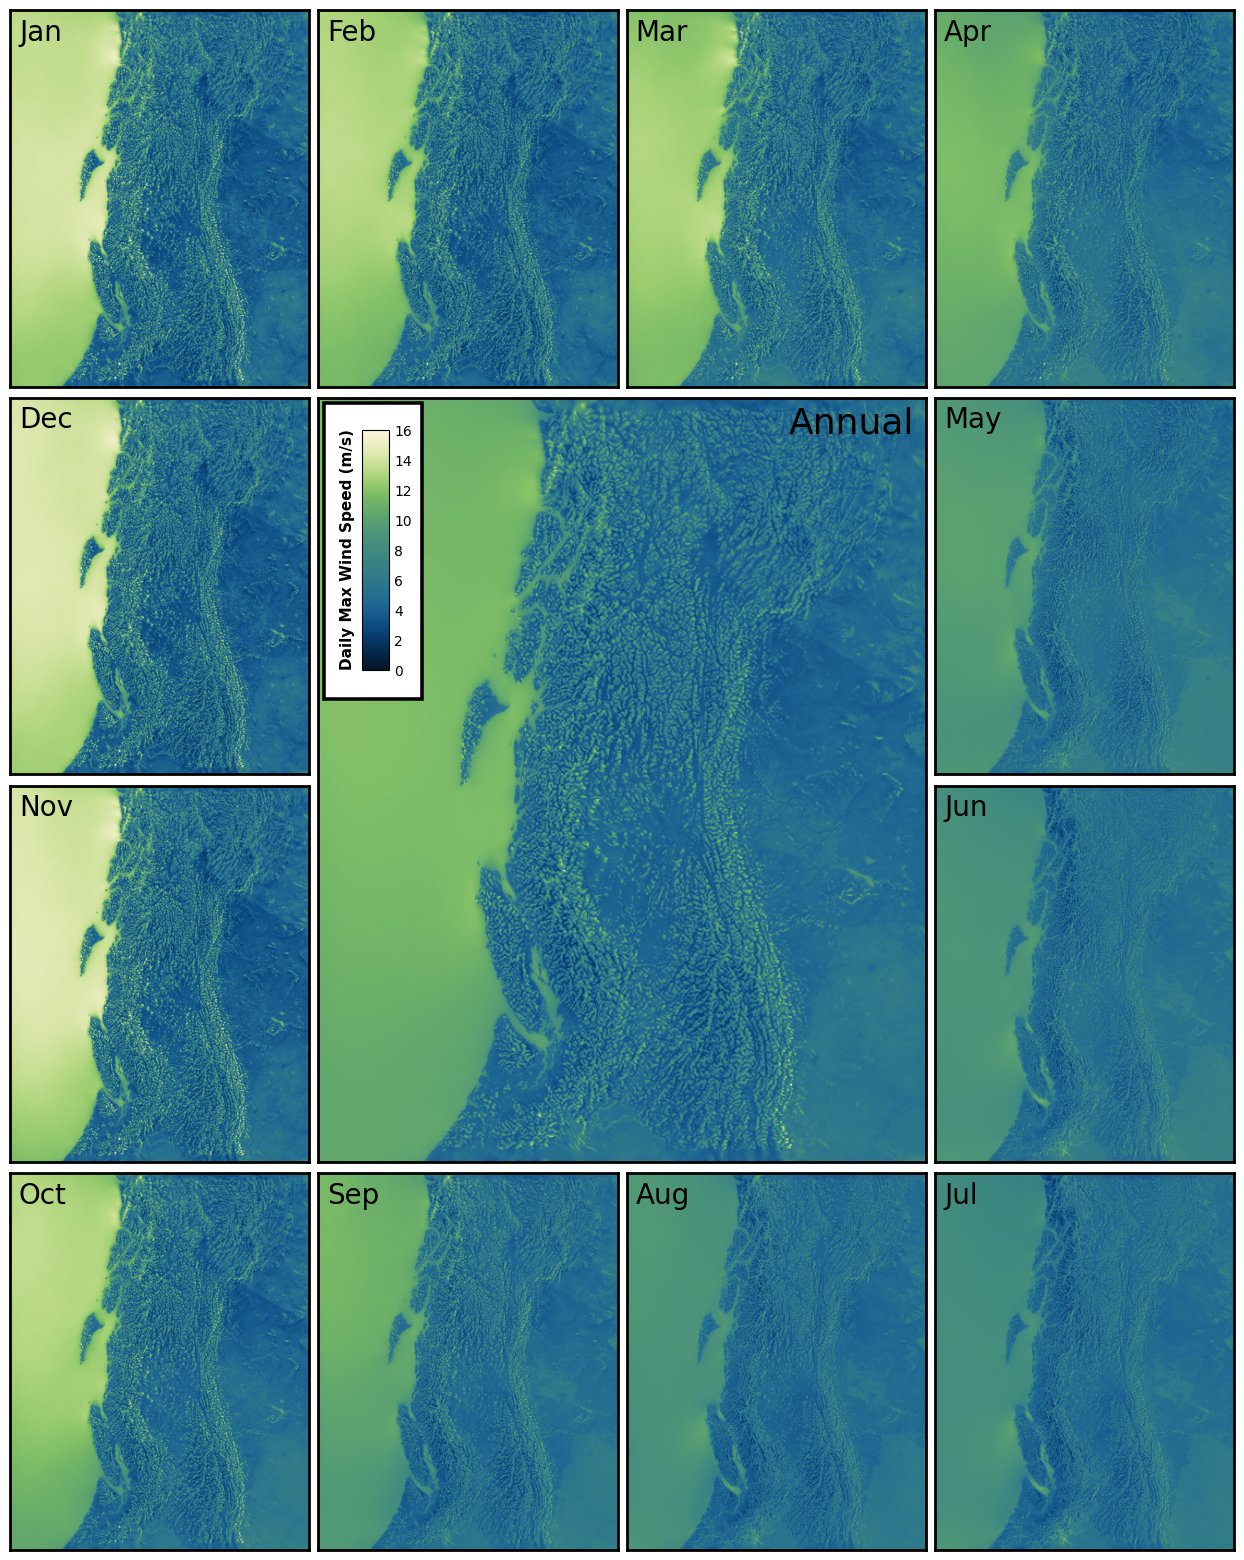

In [56]:
data = [winds_max_ymonmean_ds.isel(Times=i)['WS10'].values for i in range(12)] + [winds_max_yyearmean_ds['WS10'].values]
titles = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul',
          'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Annual']

# Set up figure and GridSpec layout
fig = plt.figure(figsize=(15.8, 20))
gs = gridspec.GridSpec(4, 4, figure=fig, wspace=0.03, hspace=0.03)

# Index map for where each panel goes (row, col)
positions = {
    'Jan':  (0, 0), 'Feb':  (0, 1), 'Mar':  (0, 2), 'Apr':  (0, 3),
    'May':  (1, 3), 'Jun':  (2, 3), 'Jul':  (3, 3), 'Aug':  (3, 2),
    'Sep':  (3, 1), 'Oct':  (3, 0), 'Nov':  (2, 0), 'Dec':  (1, 0),
    'Annual': (1, 1)  # Annual goes in the center and spans multiple rows/cols
}

# Add the plots
for i, name in enumerate(titles):
    if name == 'Annual':
        ax = fig.add_subplot(gs[1:3, 1:3])  # Larger annual plot
        ax.set_title(name, loc='right', fontsize=26, pad=-26, x=.98, y=1.000001)

        # white box on which the colorbar will be placed and its black border:
        ax.plot([50, 50],[470,652], linewidth=68, color='w', alpha=1.)
        ax.add_patch(Rectangle((6, 426), 88, 270, linewidth=4, edgecolor='black', facecolor='none', alpha=1.))

    else:
        row, col = positions[name]
        ax = fig.add_subplot(gs[row, col])
        ax.set_title(name, loc='left', fontsize=20, pad=-22, x=0.03, y=1.000001)

    im = ax.imshow(data[i], cmap=cm.navia, vmin=0, vmax=16, origin='lower',)

    ax.set_frame_on(True)
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')
        spine.set_linewidth(2)

# Add shared colorbar
cbar_ax = fig.add_axes([0.348, 0.550, 0.017, 0.12])  # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cbar_ax.yaxis.set_label_position('left')
cbar_ax.set_ylabel('Daily Max Wind Speed (m/s)', rotation=90, labelpad=5, fontsize=11, weight='bold')
cbar_ax.tick_params(axis='y', length=0)

fig.savefig('/users/rpayne/ClimatExWRF/Robert/results/WRF_UBC_WS10max_annualcycle.png', dpi=200, bbox_inches='tight')
plt.show()

/users/rpayne/venv/wx-to-fwi/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


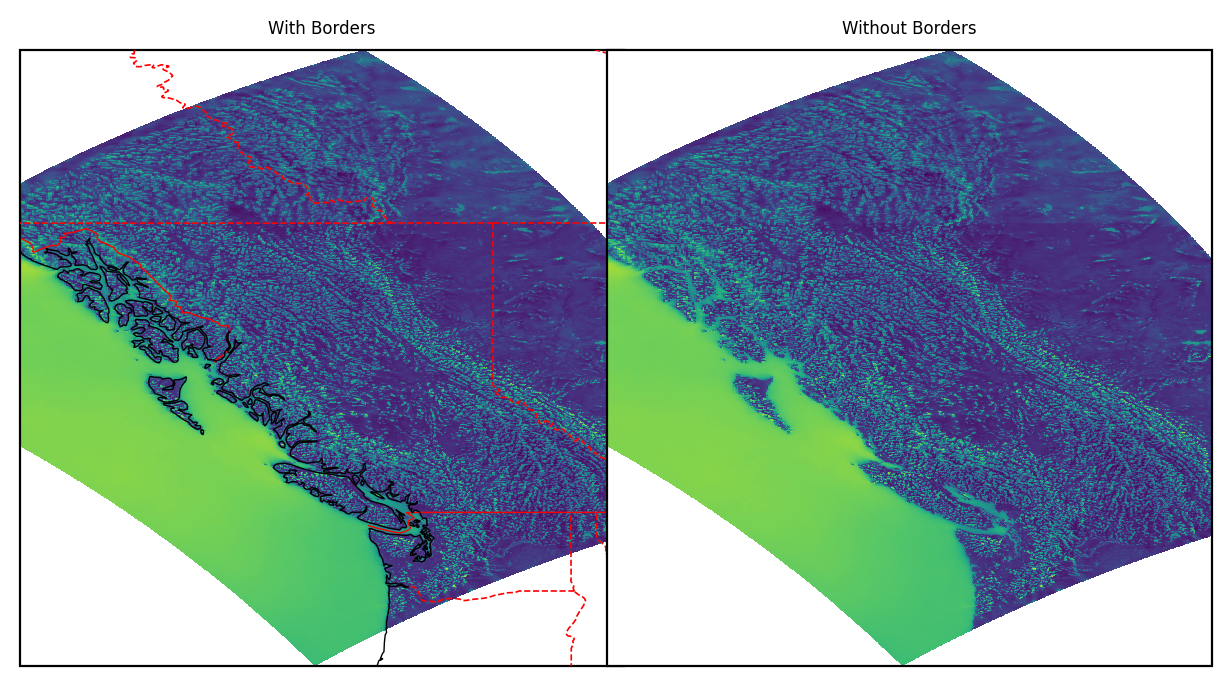

In [55]:
topography_hr = winds_max_ymonmean_ds.isel(Times=11)
lon = topography_hr['XLONG'].squeeze()
lat = topography_hr['XLAT'].squeeze()
hgt = topography_hr['WS10'].squeeze()

# Create a figure
fig, ax = plt.subplots(nrows=1,ncols=2,subplot_kw={"projection": ccrs.PlateCarree()},figsize=(8,4),dpi=200, sharex=True, sharey=True)

# Plot using pcolormesh
mesh = ax[0].pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto')
ax[0].add_feature(cfeature.BORDERS, linewidth=.5, color='r')   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='r')
ax[0].add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="r", zorder=10)

# Add coastlines and colorbar
ax[0].coastlines(lw=.5, color='k')

mesh2 = ax[1].pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto')
ax[0].set_xlim(-138, -115)
ax[1].set_xlim(-138, -115)
ax[0].set_title("With Borders", fontsize=6)
ax[1].set_title("Without Borders", fontsize=6)

plt.subplots_adjust(wspace=-.1)
plt.show()